In [ ]:
import os
# Run from the notebooks/ folder: data are read from ../data, figures are written to ../figures.
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "figures"))
os.makedirs(FIG_DIR, exist_ok=True)
os.chdir(DATA_DIR)

In [1]:
from glob import glob
import pandas as pd

In [9]:
def mapping(x):
    if x == "Qwen/Qwen2.5-0.5B-Instruct":
        return "Qwen-0.5B"
    elif x == "Qwen/Qwen2.5-1.5B-Instruct":
        return "Qwen-1.5B"
    elif x == "Qwen/Qwen2.5-3B-Instruct":
        return "Qwen-3B"
    elif x == "Qwen/Qwen2.5-7B-Instruct":
        return "Qwen-7B"
    elif x == "Qwen/Qwen2.5-14B-Instruct":
        return "Qwen-14B"
    elif x == "meta-llama/Llama-3.2-3B-Instruct":
        return "Llama-3B"
    elif x == "meta-llama/Meta-Llama-3-8B-Instruct":
        return "Llama-8B"
    elif x == "mistralai/Mistral-7B-Instruct-v0.2":
        return "Mistral-7B"
    else:
        return x

In [12]:
files = glob("spc_results_0/*metrics*")
df1 = pd.concat([pd.read_csv(file) for file in files], axis=0)
df1['n_shot'] = 0

files = glob("spc_results_1/*metrics*")
df2 = pd.concat([pd.read_csv(file) for file in files], axis=0)
df2['n_shot'] = 1

files = glob("spc_results_5/*metrics*")
df3 = pd.concat([pd.read_csv(file) for file in files], axis=0)
df3['n_shot'] = 5

df4 = pd.read_csv("lpp_new_scores.csv")[['fullname','SPC']].rename(columns={'fullname':'model_id', 'SPC': 'token_f1'})
df4['n_shot'] = 10

df = pd.concat([df1, df2, df3, df4], axis=0)[['model_id','token_f1','n_shot']]
df['model_id'] = df['model_id'].apply(mapping)

df.to_csv("all_spc.csv", index=False)

In [15]:
files = glob("ar_results_0/*metrics*")
df1 = pd.concat([pd.read_csv(file) for file in files], axis=0)
df1['n_shot'] = 0

files = glob("ar_results_1/*metrics*")
df2 = pd.concat([pd.read_csv(file) for file in files], axis=0)
df2['n_shot'] = 1

files = glob("ar_results_5/*metrics*")
df3 = pd.concat([pd.read_csv(file) for file in files], axis=0)
df3['n_shot'] = 5

df4 = pd.read_csv("lpp_new_scores.csv")[['fullname','AR']].rename(columns={'fullname':'model_id', 'AR': 'accuracy'})
df4['n_shot'] = 10

df = pd.concat([df1, df2, df3, df4], axis=0)[['model_id','accuracy','n_shot']]
df['model_id'] = df['model_id'].apply(mapping)

df.to_csv("all_ar.csv", index=False)

In [7]:
order = ['Qwen-0.5B','Qwen-1.5B','Qwen-3B','Qwen-7B','Qwen-14B','Llama-3B','Llama-8B','Mistral-7B']


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

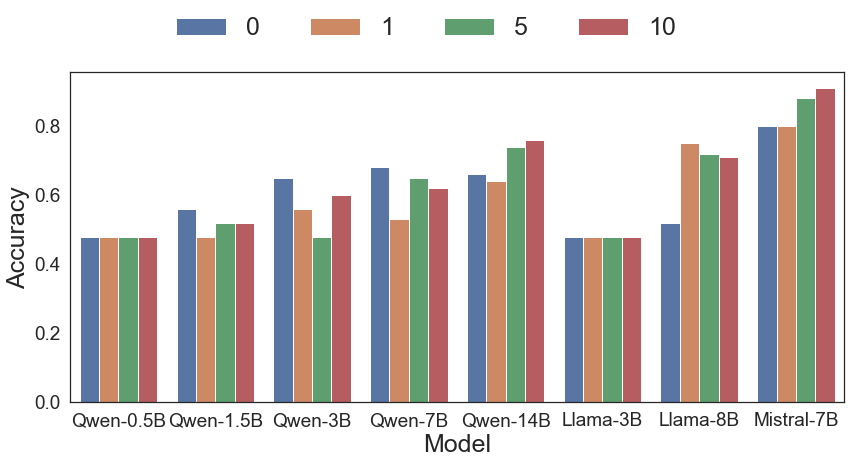

In [9]:
import os
fp = "all_ar.csv"
df = pd.read_csv(fp)

# Optional: sort models/datasets in a fixed order
model_order = sorted(df['model_id'].unique(), key=lambda x: (x.split('-')[-1] if '-' in x else x))
shot_order = sorted(df['n_shot'].unique())

df['model_id'] = pd.Categorical(df['model_id'], categories=order, ordered=True)
df['n_shot'] = pd.Categorical(df['n_shot'], categories=shot_order, ordered=True)

# --- Plot ---
sns.set_theme(style="white")
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=False)

sns.barplot(
    data=df,
    x="model_id", y="accuracy", hue="n_shot", order=order,
    ax=ax, errorbar=None, width=0.8
)
ax.set_xlabel("Model", fontsize=25)
ax.set_ylabel("Accuracy", fontsize=25)

ax.tick_params(axis='x', rotation=0, labelsize=19)
ax.tick_params(axis='y', rotation=0, labelsize=19)


# Put per-axes legend to None; we'll add one shared legend later
ax.legend_.remove()

# Shared legend (from first axes)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="", loc="upper center", ncol=4, \
           fontsize=25, frameon=False, bbox_to_anchor=(0.5, 1.1))

plt.tight_layout(rect=(0, 0, 1, 0.95))
# Optional: save to file
plt.savefig(os.path.join(FIG_DIR, "all_AR.pdf"), dpi=300, bbox_inches="tight")
#plt.show()

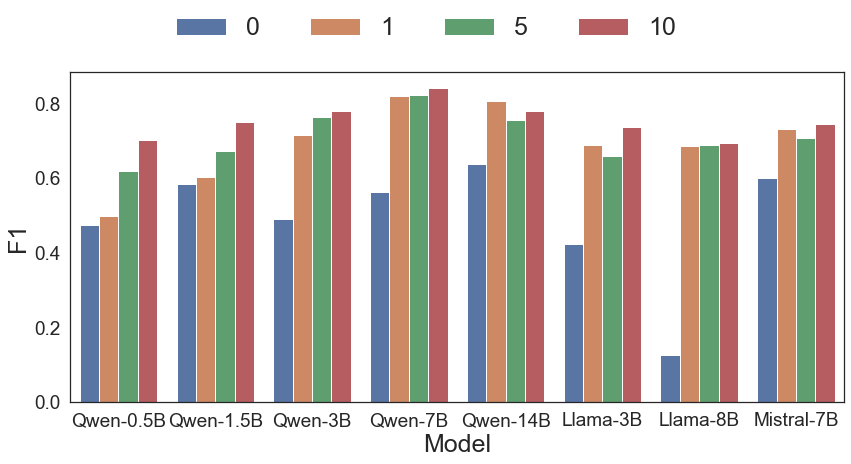

In [10]:
import os
fp = "all_spc.csv"
df = pd.read_csv(fp)

# Optional: sort models/datasets in a fixed order
model_order = sorted(df['model_id'].unique(), key=lambda x: (x.split('-')[-1] if '-' in x else x))
shot_order = sorted(df['n_shot'].unique())

df['model_id'] = pd.Categorical(df['model_id'], categories=order, ordered=True)
df['n_shot'] = pd.Categorical(df['n_shot'], categories=shot_order, ordered=True)

# --- Plot ---
sns.set_theme(style="white")
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=False)

sns.barplot(
    data=df,
    x="model_id", y="token_f1", hue="n_shot", order=order,
    ax=ax, errorbar=None, width=0.8
)
ax.set_xlabel("Model", fontsize=25)
ax.set_ylabel("F1", fontsize=25)

ax.tick_params(axis='x', rotation=0, labelsize=19)
ax.tick_params(axis='y', rotation=0, labelsize=19)

# Put per-axes legend to None; we'll add one shared legend later
ax.legend_.remove()

# Shared legend (from first axes)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="", loc="upper center", ncol=4, \
           fontsize=25, frameon=False, bbox_to_anchor=(0.5, 1.1))

plt.tight_layout(rect=(0, 0, 1, 0.95))
# Optional: save to file
plt.savefig(os.path.join(FIG_DIR, "all_SPC.pdf"), dpi=300, bbox_inches="tight")
#plt.show()